## Tarot Deck EDA
## Import libraries


In [65]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from collections import Counter

In [66]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lsind18/tarot-json/tarot-images.json
/kaggle/input/datasets/lsind18/tarot-json/cards/w05.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/w11.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/p04.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/p08.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/s07.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/c01.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/m09.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/m21.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/s14.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/c12.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/c14.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/p02.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/s12.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/w04.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/m03.jpg
/kaggle/input/datasets/lsind18/tarot-json/cards/m08.jpg
/kaggle/input/datasets/lsind18/tarot-json/ca

## Load JSON file

In [67]:
# Path to the JSON file
json_path = "/kaggle/input/datasets/lsind18/tarot-json/tarot-images.json"

# Open and load the JSON file
with open(json_path, "r") as file:
    tarot_data = json.load(file)

print(type(tarot_data))

<class 'dict'>


In [68]:
# Display all keys in the JSON file
print(tarot_data.keys())

dict_keys(['description', 'cards'])


In [69]:
print(tarot_data["description"])


tarot cards and basic information about them, as well as references to corresponding scans


In [70]:
print(type(tarot_data["cards"]))

<class 'list'>


In [71]:
print("Total Tarot Cards:", len(tarot_data["cards"]))

Total Tarot Cards: 78


In [72]:
tarot_data["cards"][0]

{'name': 'The Fool',
 'number': '0',
 'arcana': 'Major Arcana',
 'suit': 'Trump',
 'img': 'm00.jpg',
 'fortune_telling': ['Watch for new projects and new beginnings',
  'Prepare to take something on faith',
  'Something new comes your way; go for it'],
 'keywords': ['freedom', 'faith', 'inexperience', 'innocence'],
 'meanings': {'light': ['Freeing yourself from limitation',
   'Expressing joy and youthful vigor',
   'Being open-minded',
   'Taking a leap of faith',
   'Attuning yourself to your instincts',
   'Being eager or curious',
   'Exploring your potential',
   'Embracing innovation and change'],
  'shadow': ['Being gullible and naive',
   'Taking unnecessary risks',
   'Failing to be serious when required',
   'Being silly or distracted',
   'Lacking experience',
   'Failing to honor well-established traditions and limits',
   'Behaving inappropriately']},
 'Archetype': 'The Divine Madman',
 'Hebrew Alphabet': 'Aleph/Ox/1',
 'Numerology': '0 (off the scale; pure potential)',
 '

## Convert JSON to Dataframe

In [73]:
df = pd.DataFrame(tarot_data["cards"])

df.head()

,name,number,arcana,suit,img,fortune_telling,keywords,meanings,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]","{'light': ['Freeing yourself from limitation',...",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]","{'light': ['Taking appropriate action', 'Recei...",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",{'light': ['Listening to your feelings and int...,The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]","{'light': ['Nurturing yourself and others', 'B...",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]","{'light': ['Exercising authority', 'Defining l...",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,NaN,NaN


## Dataset Shape

In [74]:
df.shape

(78, 16)

### Observation: Dataset Shape

- The dataset contains **78 tarot cards**.
- Each tarot card has **16 attributes** describing its properties, meanings, and interpretations.

## Dataset Information

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   meanings            78 non-null     object
 8   Archetype           22 non-null     object
 9   Hebrew Alphabet     22 non-null     object
 10  Numerology          62 non-null     object
 11  Elemental           38 non-null     object
 12  Mythical/Spiritual  22 non-null     object
 13  Questions to Ask    78 non-null     object
 14  Astrology           40 non-null     object
 15  Affirmation         56 non-null     object
dtypes: object(16)
memory usage: 

### Observation: Dataset Information

- The dataset contains **16 columns** describing each Tarot card.
- Most columns are stored as **object** data type because they contain text, lists, or dictionaries.
- Important columns include card name, arcana, suit, meanings, fortune telling, keywords, and image filename.

## Missing values

In [76]:
df.isnull().sum()

name                   0
number                 0
arcana                 0
suit                   0
img                    0
fortune_telling        0
keywords               0
meanings               0
Archetype             56
Hebrew Alphabet       56
Numerology            16
Elemental             40
Mythical/Spiritual    56
Questions to Ask       0
Astrology             38
Affirmation           22
dtype: int64

### Observation: Missing Values

- Core columns such as **name, number, arcana, suit, image, meanings, keywords, and fortune telling** have no missing values.
- Some optional columns such as **Archetype, Hebrew Alphabet, Astrology, Elemental, and Affirmation** contain missing values.
- These missing values are expected because not every Tarot card has information for these optional attributes.

## Arcana Distribution

arcana
Minor Arcana    56
Major Arcana    22
Name: count, dtype: int64


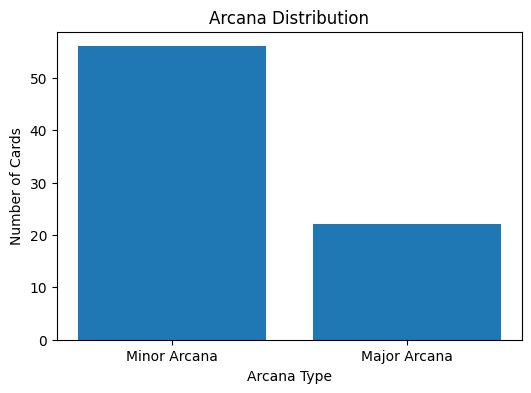

In [77]:

# Count Major and Minor Arcana cards
arcana_counts = df["arcana"].value_counts()

# Display the counts
print(arcana_counts)

# Plot the distribution
plt.figure(figsize=(6,4))
plt.bar(arcana_counts.index, arcana_counts.values)

plt.title("Arcana Distribution")
plt.xlabel("Arcana Type")
plt.ylabel("Number of Cards")

plt.show()

### Observation: Arcana Distribution

- The dataset contains **22 Major Arcana** cards and **56 Minor Arcana** cards.
- This matches the structure of a standard Tarot deck.
- Major Arcana cards represent important life events and spiritual growth.
- Minor Arcana cards represent daily life experiences, relationships, work, and emotions.

## Suit Distribution

suit
Trump        22
Cups         14
Swords       14
Wands        14
Pentacles    14
Name: count, dtype: int64


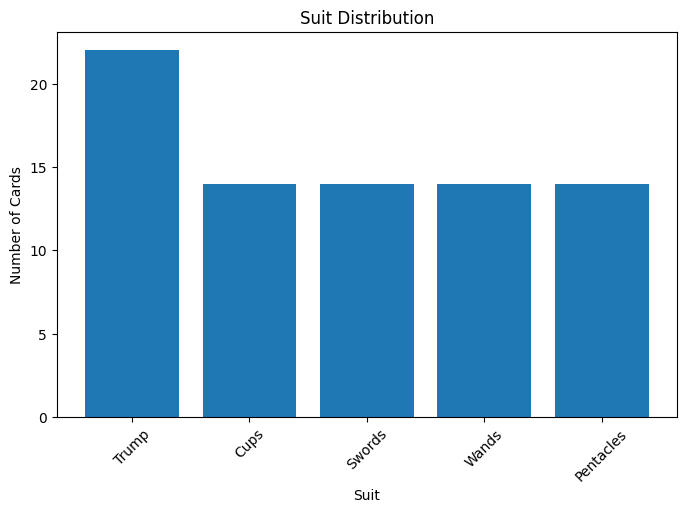

In [78]:
# Count cards in each suit
suit_counts = df["suit"].value_counts()

# Print counts
print(suit_counts)

# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(suit_counts.index, suit_counts.values)

plt.title("Suit Distribution")
plt.xlabel("Suit")
plt.ylabel("Number of Cards")

plt.xticks(rotation=45)

plt.show()

### Observation: Suit Distribution

- The Minor Arcana is evenly divided into four suits: **Cups, Pentacles, Swords, and Wands**, with **14 cards in each suit**.
- The **22 Major Arcana** cards are labeled as **Trump**.
- The distribution confirms that the dataset follows the structure of a standard Tarot deck.

## Sample Tarot Card Images

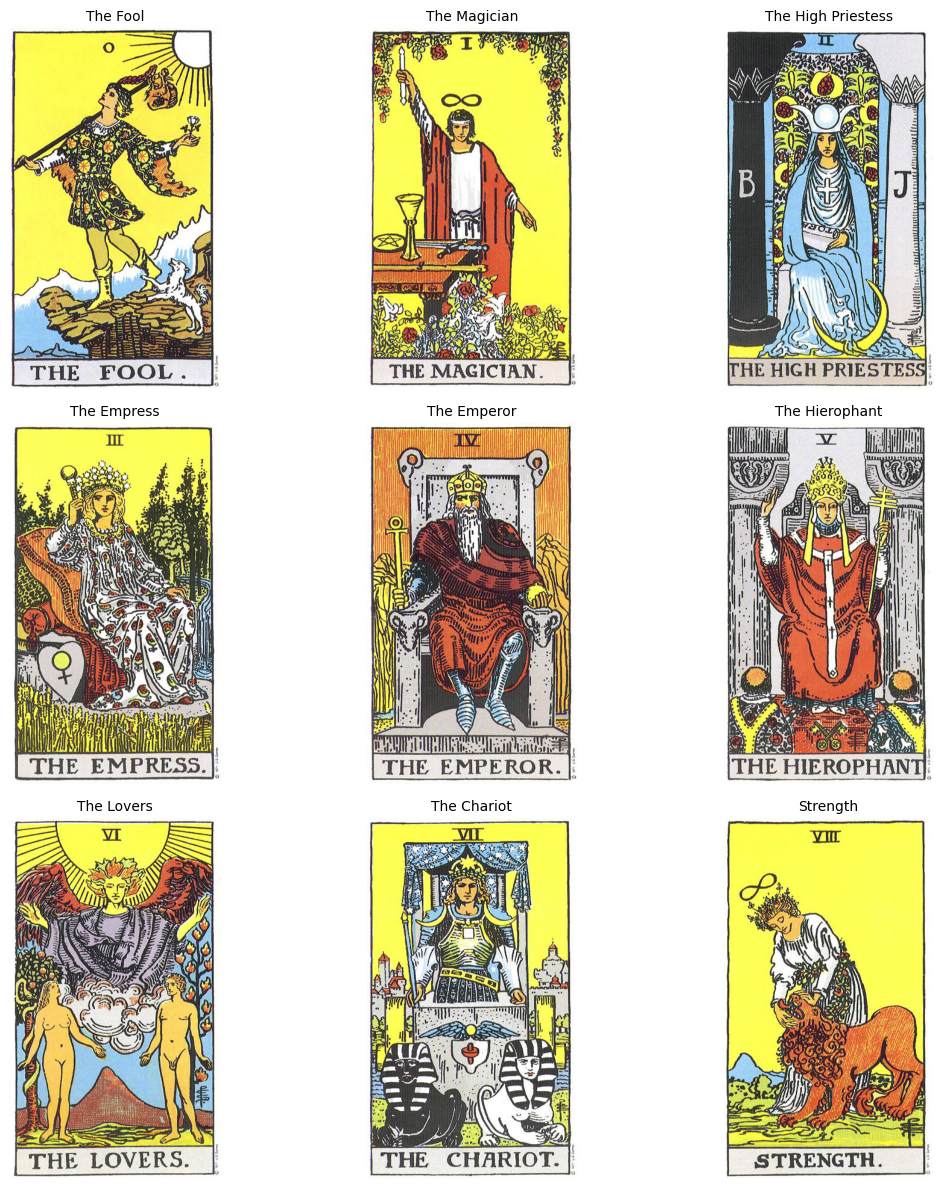

In [79]:


# Folder containing tarot card images
image_folder = "/kaggle/input/datasets/lsind18/tarot-json/cards/"

# Display 9 sample cards
plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)

    # Image filename from DataFrame
    image_name = df.iloc[i]["img"]

    # Card name
    card_name = df.iloc[i]["name"]

    # Full image path
    image_path = image_folder + image_name

    # Read image
    img = mpimg.imread(image_path)

    # Show image
    plt.imshow(img)

    # Display card name
    plt.title(card_name, fontsize=10)

    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation: Sample Tarot Card Images

- The Tarot card images were successfully loaded and displayed.
- Each image correctly matches the card name stored in the dataset.
- The images are clear and suitable for use in the AI-powered Tarot reading module.
- The dataset maintains a consistent relationship between image filenames and card metadata.

## Image Size

In [80]:

# Folder containing tarot images
image_folder = "/kaggle/input/datasets/lsind18/tarot-json/cards/"

image_sizes = []

# Read every image
for image_file in os.listdir(image_folder):

    image_path = os.path.join(image_folder, image_file)

    img = Image.open(image_path)

    image_sizes.append(img.size)

# Count image sizes
size_counts = Counter(image_sizes)

print(size_counts)

Counter({(350, 600): 78})


### Observation: Image Size Consistency

- All **78 Tarot card images** have the same resolution of **350 × 600 pixels**.
- The dataset has consistent image dimensions.
- Uniform image sizes simplify preprocessing and make the dataset suitable for visualization and future deep learning applications.

## Textual Content Analysis

In [81]:
# Count keywords for each card
df["keyword_count"] = df["keywords"].apply(len)

print(df[["name", "keyword_count"]].head())
print("\nAverage keywords per card:", df["keyword_count"].mean())

                 name  keyword_count
0            The Fool              4
1        The Magician              3
2  The High Priestess              4
3         The Empress              4
4         The Emperor              4

Average keywords per card: 4.346153846153846


In [82]:
df["fortune_count"] = df["fortune_telling"].apply(len)

print(df[["name", "fortune_count"]].head())
print("\nAverage fortune-telling statements:", df["fortune_count"].mean())

                 name  fortune_count
0            The Fool              3
1        The Magician              2
2  The High Priestess              3
3         The Empress              3
4         The Emperor              3

Average fortune-telling statements: 2.051282051282051


In [83]:
df["question_count"] = df["Questions to Ask"].apply(len)

print(df[["name", "question_count"]].head())
print("\nAverage questions per card:", df["question_count"].mean())

                 name  question_count
0            The Fool               3
1        The Magician               3
2  The High Priestess               3
3         The Empress               3
4         The Emperor               3

Average questions per card: 2.9871794871794872


### Observation: Textual Content Analysis

- Each Tarot card contains an average of **4–5 keywords** describing its symbolism.
- Each card includes approximately **2–3 fortune-telling statements**.
- Almost every card provides **3 reflection questions** to encourage self-analysis.
- The dataset contains rich textual information that can be used to generate meaningful and interactive Tarot readings.

# Final EDA Conclusion

## Dataset Summary

- The dataset contains **78 Tarot cards** with **16 attributes**.
- The cards include both textual information and corresponding images.
- All card images have a consistent resolution of **350 × 600 pixels**.

## Data Quality

- Core fields such as **name, arcana, suit, image, keywords, meanings, fortune telling, and questions to ask** contain no missing values.
- Some optional fields such as **Archetype, Astrology, Elemental, and Hebrew Alphabet** contain missing values, which is expected because these attributes are not applicable to every card.

## Tarot Structure

- The dataset follows the standard Tarot deck structure:
  - **22 Major Arcana** cards
  - **56 Minor Arcana** cards
- The Minor Arcana is evenly distributed among the four suits:
  - Cups
  - Pentacles
  - Swords
  - Wands

## Textual Content

- Each card contains rich descriptive information, including:
  - Keywords
  - Fortune-telling statements
  - Positive and shadow meanings
  - Reflection questions
- This rich textual content makes the dataset suitable for AI-generated Tarot interpretations.

## Project-Specific Findings

For the **Palmistry & Tarot Intelligence Platform**, this dataset can be used to:

- Display Tarot card images.
- Generate personalized Tarot interpretations.
- Provide fortune-telling guidance.
- Present positive and shadow meanings.
- Ask reflection questions to create an interactive user experience.

Overall, the dataset is well-structured, complete, and suitable for integration into an AI-powered Tarot reading system.